# Embeddings: el codigo de barras del tejido

Ya tenemos los parches. El siguiente paso es convertir cada uno en un vector de numeros
que capture que hay dentro, para poder clasificar, agrupar o buscar tejido parecido.

Este notebook compara tres familias de extractores, mide cuando se distinguen entre si, y
prueba lo unico que de verdad importa en patologia computacional: si sobreviven a un
cambio de laboratorio.

**Requisitos:** `numpy`, `scikit-image`, `scikit-learn`, `umap-learn`, `matplotlib`.

In [1]:
import numpy as np, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt, umap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
VERDE, ROJO, AZUL, NARANJA, TINTA = '#0b6e5f', '#c0392b', '#2c5f8a', '#b8730a', '#333'

## 1. Que es un embedding

Un extractor de caracteristicas toma una imagen y devuelve un vector. La idea es que
imagenes parecidas produzcan vectores cercanos, de modo que problemas dificiles en el
espacio de pixeles (96x96x3 = 27,648 dimensiones) se vuelvan faciles en un espacio de unas
decenas o cientos.

Ese vector se llama embedding, y la propiedad que buscamos es que **la distancia entre
vectores refleje la similitud biologica**, no la similitud superficial de color.

Vamos a comparar tres formas de obtenerlo, de la mas simple a la mas sofisticada.

In [2]:
"""Genera una WSI sintetica con estructura histologica H&E creible."""
import numpy as np
from scipy import ndimage as ndi

def tejido_he(alto, ancho, semilla=7, densidad_nuclear=1.0, escala=1.0):
    """Tejido tenido con hematoxilina-eosina.

    Estroma rosa (eosina) + nucleos morados (hematoxilina). La densidad
    nuclear distingue tumor de tejido sano: el tumor es hipercelular.
    """
    rng = np.random.default_rng(semilla)
    # estroma: textura fibrilar rosa
    # estroma fibrilar: dos escalas de textura
    fino = ndi.gaussian_filter(rng.random((alto, ancho)), 1.2)
    grueso = ndi.zoom(ndi.gaussian_filter(rng.random((alto//16, ancho//16)), 2.0),
                      16, order=1)[:alto, :ancho]
    base = 0.45*(fino-fino.mean())/max(fino.std(),1e-6)*0.5 + 0.55*grueso
    img = np.zeros((alto,ancho,3), np.float32)
    img[...,0] = 0.88 - 0.10*base    # R
    img[...,1] = 0.70 - 0.18*base    # G
    img[...,2] = 0.82 - 0.08*base    # B

    # nucleos: elipses moradas
    n = int(densidad_nuclear * alto*ancho / 320)
    ys = rng.integers(0, alto, n); xs = rng.integers(0, ancho, n)
    rr = rng.normal(3.2*escala, 0.9*escala, n).clip(1.6, 9.0)
    mascara = np.zeros((alto,ancho), np.float32)
    yy,xx = np.ogrid[:alto,:ancho]
    # dibujo vectorizado por bloques para no reventar memoria
    for y,x,r in zip(ys,xs,rr):
        y0,y1 = max(0,int(y-r*2)), min(alto,int(y+r*2)+1)
        x0,x1 = max(0,int(x-r*2)), min(ancho,int(x+r*2)+1)
        if y1<=y0 or x1<=x0: continue
        sy,sx = np.ogrid[y0:y1, x0:x1]
        ex = r*rng.uniform(0.65, 1.0)          # elipticidad variable
        d = ((sy-y)/r)**2 + ((sx-x)/ex)**2
        mascara[y0:y1,x0:x1] = np.maximum(mascara[y0:y1,x0:x1], np.exp(-d*1.9))
    img[...,0] -= 0.46*mascara
    img[...,1] -= 0.50*mascara
    img[...,2] -= 0.12*mascara
    return np.clip(img,0,1), mascara

def wsi(alto=8192, ancho=8192, semilla=7):
    """WSI completa: cristal vacio, tejido en forma irregular, foco tumoral."""
    rng = np.random.default_rng(semilla)
    img = np.ones((alto,ancho,3), np.float32)*0.985     # cristal
    img += rng.normal(0,0.004,(alto,ancho,3))           # ruido del escaner

    # forma del tejido: mancha irregular que NO llena el porta
    campo = rng.random((32,32))
    campo = ndi.zoom(ndi.gaussian_filter(campo,2.2), (alto/32, ancho/32), order=3)
    forma = campo > np.percentile(campo, 58)
    forma = ndi.binary_closing(forma, np.ones((25,25)))
    forma = ndi.binary_opening(forma, np.ones((25,25)))

    sano,_ = tejido_he(alto,ancho,semilla=semilla, densidad_nuclear=1.0)
    img[forma] = sano[forma]

    # foco tumoral: hipercelular, dentro del tejido
    cy,cx = int(alto*0.62), int(ancho*0.40)
    R = int(min(alto,ancho)*0.13)
    yy,xx = np.ogrid[:alto,:ancho]
    borde = ndi.zoom(ndi.gaussian_filter(rng.random((24,24)),1.6),
                     (alto/24,ancho/24), order=3)
    tumor = (((yy-cy)**2+(xx-cx)**2) < (R*(0.75+0.5*borde))**2) & forma
    tum,_ = tejido_he(alto,ancho,semilla=semilla+1, densidad_nuclear=3.1, escala=1.15)
    img[tumor] = tum[tumor]
    return (np.clip(img,0,1)*255).astype(np.uint8), forma, tumor

In [3]:
"""Genera parches etiquetados de tejido sano y tumoral, con variacion de tincion."""
import numpy as np


def lote(n, densidad, semilla, P=96, tincion=None):
    """n parches de PxP con la densidad nuclear dada.

    tincion: (escala_R, escala_G, escala_B) para simular otro laboratorio.
    """
    rng=np.random.default_rng(semilla)
    X=np.zeros((n,P,P,3),np.uint8)
    grande,_ = tejido_he(P*8, P*8, semilla=semilla, densidad_nuclear=densidad)
    for k in range(n):
        y=rng.integers(0,P*8-P); x=rng.integers(0,P*8-P)
        p=grande[y:y+P, x:x+P].copy()
        if tincion is not None:
            p = np.clip(p*np.array(tincion,np.float32), 0, 1)
        X[k]=(p*255).astype(np.uint8)
    return X

def conjunto(n_por_clase=300, semilla=7, tincion=None, P=96):
    sano  = lote(n_por_clase, 1.0, semilla,   P=P, tincion=tincion)
    tumor = lote(n_por_clase, 3.1, semilla+1, P=P, tincion=tincion)
    X=np.concatenate([sano,tumor]); y=np.r_[np.zeros(n_por_clase,int), np.ones(n_por_clase,int)]
    return X,y

In [4]:
"""Tres familias de extractores de caracteristicas, de simple a sofisticado."""
import numpy as np
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.color import rgb2gray, rgb2hsv

def color(X):
    """Estadisticas de color: lo mas simple que puede funcionar."""
    F=[]
    for im in X:
        a=im.astype(np.float32)/255
        h=rgb2hsv(a)
        F.append(np.r_[a.mean((0,1)), a.std((0,1)),
                       h.mean((0,1)), h.std((0,1)),
                       np.percentile(a.reshape(-1,3),[10,50,90],axis=0).ravel()])
    return np.array(F)

def textura(X, P=8, R=1.0):
    """Descriptores clasicos de textura: LBP + matriz de coocurrencia (Haralick)."""
    F=[]
    for im in X:
        g=(rgb2gray(im)*255).astype(np.uint8)
        lbp=local_binary_pattern(g, P, R, method='uniform')
        hist,_=np.histogram(lbp, bins=P+2, range=(0,P+2), density=True)
        glcm=graycomatrix(g//8, distances=[1,3], angles=[0,np.pi/4,np.pi/2,3*np.pi/4],
                          levels=32, symmetric=True, normed=True)
        props=[graycoprops(glcm,p).ravel() for p in
               ('contrast','homogeneity','energy','correlation')]
        F.append(np.r_[hist, np.concatenate(props)])
    return np.array(F)

_BANCO=None
def _banco(semilla=0, n=64, k=7):
    global _BANCO
    if _BANCO is None:
        rng=np.random.default_rng(semilla)
        f=rng.standard_normal((n,3,k,k)).astype(np.float32)
        f-=f.mean((1,2,3),keepdims=True)
        f/=(np.sqrt((f**2).sum((1,2,3),keepdims=True))+1e-8)
        _BANCO=f
    return _BANCO

def random_cnn(X, n=64, k=7):
    """Convoluciones ALEATORIAS + pooling estadistico.

    No hay entrenamiento ni preentrenamiento: mide cuanto aporta la
    arquitectura por si sola, antes de aprender nada.
    """
    from scipy.signal import fftconvolve
    f=_banco(n=n,k=k); F=[]
    for im in X:
        a=(im.astype(np.float32)/255)
        a=(a-a.mean((0,1)))/(a.std((0,1))+1e-6)
        v=[]
        for filtro in f:
            r=sum(fftconvolve(a[...,c], filtro[c][::-1,::-1], mode='valid')
                  for c in range(3))
            r=np.maximum(r,0)                      # ReLU
            v += [r.mean(), r.std(), r.max()]      # pooling estadistico
        F.append(np.array(v))
    return np.array(F)

La tercera merece una nota. **La CNN aleatoria no esta entrenada ni preentrenada**: son
convoluciones con pesos al azar seguidas de ReLU y pooling estadistico. Sirve para medir
cuanto aporta la arquitectura convolucional por si sola, antes de aprender nada. Es un
baseline clasico y sorprendentemente fuerte.

Lo que no podemos ejecutar aqui son los extractores reales de la literatura — ResNet
preentrenada, y sobre todo modelos fundacionales de patologia como UNI2-h. Al final del
notebook esta el codigo para hacerlo.

## 2. Cuando el problema es facil, todos ganan

In [5]:
X, y = conjunto(250)          # tumor 3.1x mas denso que el tejido sano
print(f'{X.shape[0]} parches de {X.shape[1]}x{X.shape[2]}, clases {np.bincount(y)}')

EXT = [('Color', color), ('Textura', textura), ('CNN aleatoria', random_cnn)]
print(f'\n{"extractor":>16} | {"dims":>5} | {"AUC":>8}')
print('-'*36)
for nombre, f in EXT:
    F = f(X)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=4000))
    auc = cross_val_score(clf, F, y, cv=5, scoring='roc_auc').mean()
    print(f'{nombre:>16} | {F.shape[1]:>5} | {auc:>8.4f}')

500 parches de 96x96, clases [250 250]

       extractor |  dims |      AUC
------------------------------------


           Color |    21 |   1.0000


         Textura |    42 |   1.0000


   CNN aleatoria |   192 |   1.0000


AUC de 1.0000 en los tres. Sin diferencias.

Es un resultado inutil, y la razon es que el problema esta mal planteado: una diferencia de
3.1x en densidad nuclear la detecta cualquier cosa, incluso el color medio del parche.

**Si evaluas extractores con un contraste fuerte, concluyes que todos son iguales.** Es uno
de los errores mas comunes al comparar metodos.

## 3. Barrer la dificultad

In [6]:
def datos(densidad_tumor, n=200, semilla=7, tincion=None):
    sano = lote(n, 1.00, semilla, tincion=tincion)
    tumor = lote(n, densidad_tumor, semilla+1, tincion=tincion)
    return np.concatenate([sano, tumor]), np.r_[np.zeros(n, int), np.ones(n, int)]


print(f'{"densidad tumoral":>17} |' + ''.join(f'{n:>16}' for n, _ in EXT))
print('-'*68)
curvas = []
for d in (1.15, 1.30, 1.50, 1.80, 2.20, 3.10):
    Xd, yd = datos(d)
    fila = f'{d:>15.2f}x |'; vals = [d]
    for nombre, f in EXT:
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=4000))
        auc = cross_val_score(clf, f(Xd), yd, cv=5, scoring='roc_auc').mean()
        fila += f'{auc:>16.4f}'; vals.append(auc)
    print(fila); curvas.append(vals)
curvas = np.array(curvas)

 densidad tumoral |           Color         Textura   CNN aleatoria
--------------------------------------------------------------------


           1.15x |          0.6654          0.8131          0.8271


           1.30x |          0.8172          0.8802          0.9217


           1.50x |          0.9170          0.9585          0.9750


           1.80x |          0.9871          0.9950          0.9955


           2.20x |          0.9990          1.0000          0.9996


           3.10x |          1.0000          1.0000          1.0000


Ahora si aparece la jerarquia. En el regimen dificil (1.15x): color 0.665, textura 0.813,
CNN aleatoria 0.827.

Dos lecturas.

**El orden es el esperado**, y confirma la intuicion: mas capacidad de representacion, mas
separabilidad. Que una red con pesos *aleatorios* supere a descriptores disenados a mano
dice algo sobre cuanto aporta la estructura convolucional por si sola.

**El ranking solo existe en el regimen dificil.** A partir de 2.2x todos empatan en 1.0. El
punto de operacion en el que evalues determina que conclusion saques.

## 4. El espacio latente

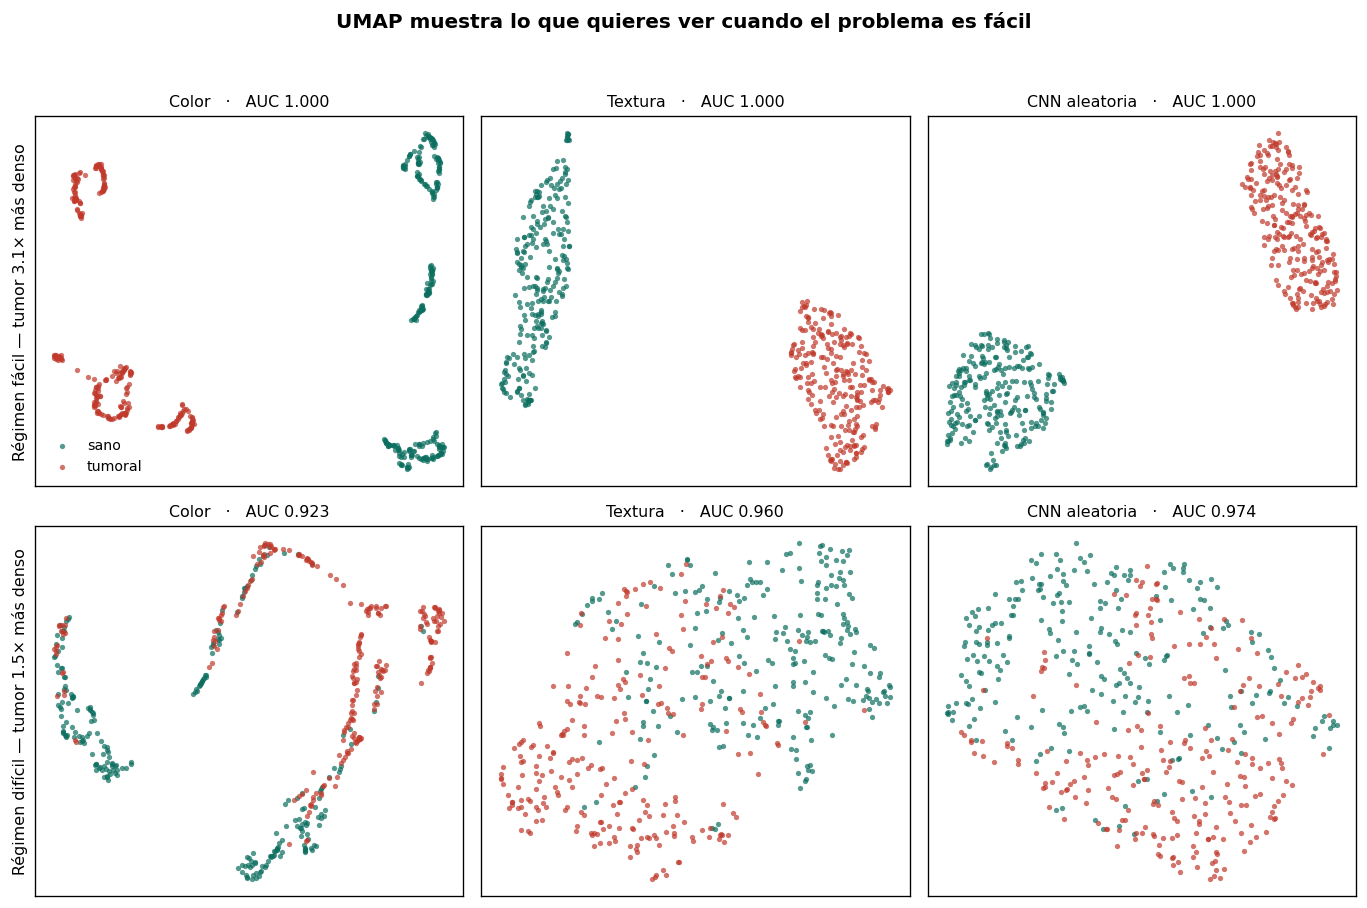

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.6))
for fila, (d, etq) in enumerate([(3.1, 'Régimen fácil — tumor 3.1× más denso'),
                                 (1.5, 'Régimen difícil — tumor 1.5× más denso')]):
    Xd, yd = datos(d, n=250)
    for col, (nombre, f) in enumerate(EXT):
        F = StandardScaler().fit_transform(f(Xd))
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=4000))
        auc = cross_val_score(clf, F, yd, cv=5, scoring='roc_auc').mean()
        Z = umap.UMAP(n_neighbors=20, min_dist=0.15, random_state=0).fit_transform(F)
        ax = axes[fila, col]
        ax.scatter(Z[yd==0,0], Z[yd==0,1], s=10, c=VERDE, alpha=0.7, lw=0, label='sano')
        ax.scatter(Z[yd==1,0], Z[yd==1,1], s=10, c=ROJO, alpha=0.7, lw=0, label='tumoral')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'{nombre}   ·   AUC {auc:.3f}', fontsize=9.5)
    axes[fila, 0].set_ylabel(etq, fontsize=9.5)
axes[0,0].legend(loc='best', frameon=False, fontsize=8.5)
fig.suptitle('UMAP muestra lo que quieres ver cuando el problema es fácil',
             fontweight='bold', y=0.99)
fig.tight_layout(rect=[0,0,1,0.96])
plt.show()

UMAP proyecta el espacio de caracteristicas a dos dimensiones preservando la estructura
local de vecindad. Arriba, con el problema facil, los clusteres se separan limpiamente —
esa es la figura que todo el mundo publica.

Abajo, con el problema dificil, la proyeccion es un revoltijo. Y sin embargo **el
clasificador sigue logrando AUC de 0.92 a 0.97 sobre esos mismos datos**.

La leccion: **UMAP visualiza, no mide.** Que dos clases no se separen en la proyeccion 2D
no significa que no sean separables en el espacio original. Un UMAP bonito es una
ilustracion, no evidencia.

## 5. La prueba que importa: cambiar de laboratorio

Dos laboratorios tiñen distinto. Distinta concentracion de hematoxilina, distinto tiempo de
exposicion, distinto escaner. Un modelo entrenado en uno tiene que funcionar en el otro, y
ese es el principal problema de generalizacion en patologia computacional.

In [8]:
TINCION_B = (0.86, 0.98, 1.20)     # otro laboratorio: más azulado, más pálido
D = 1.5                             # régimen donde los extractores se distinguen

XA, yA = datos(D, n=250)
XB, yB = datos(D, n=250, semilla=31, tincion=TINCION_B)

print(f'{"extractor":>16} | {"AUC lab A":>10} | {"AUC lab B":>10} | {"caída":>8}')
print('-'*54)
modelos = {}
for nombre, f in EXT:
    FA = f(XA)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=4000))
    a = cross_val_score(clf, FA, yA, cv=5, scoring='roc_auc').mean()
    clf.fit(FA, yA); modelos[nombre] = clf
    b = roc_auc_score(yB, clf.predict_proba(f(XB))[:,1])
    print(f'{nombre:>16} | {a:>10.4f} | {b:>10.4f} | {100*(b-a)/a:>7.1f}%')

       extractor |  AUC lab A |  AUC lab B |    caída
------------------------------------------------------


           Color |     0.9234 |     0.8316 |    -9.9%


         Textura |     0.9602 |     0.8926 |    -7.0%


   CNN aleatoria |     0.9741 |     0.8393 |   -13.8%


Los tres caen. Y hay una inversion interesante: **la CNN aleatoria es la mejor dentro del
mismo laboratorio (0.974) y la que peor generaliza (−13.8%)**. Mas capacidad de
representacion significa tambien mas capacidad de sobreajustarse a la tincion.

La textura es la mas robusta (−7.0%), lo cual tiene sentido: LBP y las propiedades de
Haralick se calculan sobre la imagen en gris, asi que son parcialmente indiferentes al
color.

Aqui esta exactamente la razon de que existan los modelos fundacionales de patologia. UNI2-h
se entreno sobre mas de 200 millones de parches de 350,000 laminas de multiples fuentes;
esa diversidad es lo que le permite aprender representaciones robustas a la tincion, algo
que ni un descriptor hecho a mano ni una red aleatoria pueden lograr.

## 6. Normalizacion de tincion, y el error que casi todos cometen

In [9]:
import numpy as np
from skimage.color import rgb2lab, lab2rgb

def reinhard(X, ref_media, ref_std):
    """Normalizacion de tincion de Reinhard: iguala media y desviacion en LAB.

    Es la mas simple de las normalizaciones de tincion. Macenko y Vahadane
    hacen algo mas sofisticado (separan los vectores de tincion H y E),
    pero Reinhard captura la idea y no necesita deconvolucion.
    """
    Y=np.empty_like(X)
    for k,im in enumerate(X):
        lab=rgb2lab(im.astype(np.float32)/255)
        m,s = lab.mean((0,1)), lab.std((0,1))+1e-6
        lab=(lab-m)/s*ref_std + ref_media
        Y[k]=(np.clip(lab2rgb(lab),0,1)*255).astype(np.uint8)
    return Y

def estadisticas(X):
    L=np.stack([rgb2lab(im.astype(np.float32)/255) for im in X])
    return L.mean((0,1,2)), L.std((0,1,2))


def reinhard_lamina(X, ref_media, ref_std, media_origen=None, std_origen=None):
    """Reinhard con estadisticas de LAMINA, no de parche.

    Diferencia critica: se estima una sola transformacion para toda la
    laminilla y se aplica igual a todos sus parches. Normalizar cada parche
    con sus propias estadisticas borra la senal, porque la densidad nuclear
    -- que es justo lo que distingue tumor de sano -- cambia las
    estadisticas de color del parche.
    """
    if media_origen is None:
        media_origen, std_origen = estadisticas(X)
    Y=np.empty_like(X)
    for k,im in enumerate(X):
        lab=rgb2lab(im.astype(np.float32)/255)
        lab=(lab-media_origen)/(std_origen+1e-6)*ref_std + ref_media
        Y[k]=(np.clip(lab2rgb(lab),0,1)*255).astype(np.uint8)
    return Y

In [10]:
media_ref, std_ref = estadisticas(XA)

XB_parche = reinhard(XB, media_ref, std_ref)          # cada parche con SUS estadísticas
XB_lamina = reinhard_lamina(XB, media_ref, std_ref)   # una transformación para toda la lámina

print(f'{"extractor":>16} |{"sin normalizar":>15} |{"por PARCHE":>12} |{"por LÁMINA":>12}')
print('-'*60)
for nombre, f in EXT:
    clf = modelos[nombre]
    a = roc_auc_score(yB, clf.predict_proba(f(XB))[:,1])
    b = roc_auc_score(yB, clf.predict_proba(f(XB_parche))[:,1])
    c = roc_auc_score(yB, clf.predict_proba(f(XB_lamina))[:,1])
    print(f'{nombre:>16} |{a:>15.4f} |{b:>12.4f} |{c:>12.4f}')

       extractor | sin normalizar |  por PARCHE |  por LÁMINA
------------------------------------------------------------


           Color |         0.8316 |      0.2817 |      0.8631


         Textura |         0.8926 |      0.7274 |      0.8940


   CNN aleatoria |         0.8393 |      0.8437 |      0.8275


Normalizar cada parche por separado **destruye la senal**: el color cae a AUC 0.28, peor
que el azar.

La explicacion es directa y vale la pena interiorizarla. Reinhard iguala la media y la
desviacion de cada imagen a una referencia. Pero la senal que distingue tumor de sano *es*
la densidad nuclear, y la densidad nuclear cambia la media de color del parche. Al
normalizar parche por parche, se borra exactamente aquello que se queria detectar.

La forma correcta es estimar **una sola transformacion por laminilla** y aplicarla igual a
todos sus parches. Asi se corrige la diferencia entre laboratorios y se preserva la
variacion dentro de la lamina, que es la informacion util.

Con normalizacion por lamina el color no solo se recupera: supera al valor sin normalizar
(0.863 contra 0.832).

## 7. Con extractores reales

El codigo siguiente no se ejecuta aqui — requiere PyTorch y descargar pesos.

### ResNet preentrenada en ImageNet

```python
import torch, timm
modelo = timm.create_model('resnet50', pretrained=True, num_classes=0)  # sin cabeza
modelo.eval()

@torch.no_grad()
def embeddings(parches, modelo, bs=64):
    # parches: (N, 224, 224, 3) uint8
    salida = []
    media = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
    desv  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)
    for i in range(0, len(parches), bs):
        x = torch.from_numpy(parches[i:i+bs]).permute(0,3,1,2).float()/255
        x = (x - media)/desv
        salida.append(modelo(x).cpu().numpy())
    return np.concatenate(salida)
```

Devuelve 2048 dimensiones por parche.

### UNI2-h (modelo fundacional de patologia)

UNI2-h se distribuye bajo licencia **CC-BY-NC-ND 4.0**: solo uso academico no comercial,
con atribucion, y el acceso requiere registro previo en Hugging Face con correo
institucional. Al descargarlo se acepta **no redistribuir los pesos**, asi que ningun
repositorio debe incluirlos.

```python
# requiere haber solicitado y obtenido acceso en huggingface.co/MahmoodLab/UNI2-h
import timm, torch
from huggingface_hub import login
login(token='TU_TOKEN')

modelo = timm.create_model(
    'hf-hub:MahmoodLab/UNI2-h', pretrained=True, init_values=1e-5, dynamic_img_size=True)
modelo.eval()
# mismo bucle de embeddings; devuelve 1536 dimensiones por parche
```

MahmoodLab tambien publica **embeddings ya extraidos** para TCGA, CPTAC y PANDA, bajo la
misma licencia. Si solo necesitas las caracteristicas y no el modelo, es el camino corto.

### Que esperar

Sobre datos reales, la jerarquia documentada en la literatura es: descriptores clasicos <
ResNet de ImageNet < modelos fundacionales de patologia. La brecha se agranda cuanto mas
dificil es la tarea y mas distinto es el laboratorio de evaluacion — exactamente las dos
dimensiones que medimos aqui.

## Donde falla esto

**El tejido es sintetico y la tarea es una sola.** Distinguir por densidad nuclear es solo
uno de los criterios reales; arquitectura glandular, invasion de bordes y patron de
crecimiento no estan modelados.

**La variacion de tincion tambien es sintetica.** Multiplicar canales RGB es una
aproximacion cruda; la variacion real afecta de forma no lineal a cada tincion por
separado, y por eso existen metodos de deconvolucion como Macenko y Vahadane.

**La CNN aleatoria no sustituye a una preentrenada.** Es un baseline util para razonar,
no una recomendacion practica.

**No se midio robustez a magnificacion**, que en datos reales es tan importante como la
tincion.

## Referencias

- Chen R.J. et al. *Towards a general-purpose foundation model for computational pathology
  (UNI).* Nature Medicine, 2024.
- Reinhard E. et al. *Color transfer between images.* IEEE Computer Graphics and
  Applications, 2001.
- Macenko M. et al. *A method for normalizing histology slides for quantitative analysis.*
  ISBI, 2009.
- McInnes L., Healy J., Melville J. *UMAP: Uniform Manifold Approximation and Projection.*
  arXiv:1802.03426, 2018.